## HOME LOAN AUTOMATED ANALYTICS PROJECT
# Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load all 6 sheets



Customer,
Channel,
Product,
Branch,
Sanction,
Recovery

In [3]:
file = "D:\data science\project\home loans project\Home+Loans+Dataset.xlsx"

sheets = pd.read_excel("D:\data science\project\home loans project\Home+Loans+Dataset.xlsx", sheet_name=None)

In [4]:
customer = sheets['Customer']
channel = sheets['Channel']
product = sheets['Product']
branch = sheets['Branch']
sanction = sheets['Sanction Data']
recovery = sheets['Recovery Data']

In [5]:
# check duplicates
print("Customer duplicates:", customer.duplicated().sum())
print("Sanction duplicates:", sanction.duplicated().sum())
print("Recovery duplicates:", recovery.duplicated().sum())

Customer duplicates: 0
Sanction duplicates: 0
Recovery duplicates: 0


## Automated data cleaning

In [6]:
def clean_data(df):

    # Remove duplicate rows
    df = df.drop_duplicates()

    # Clean column names
    df.columns = df.columns.str.strip()

    # Clean text columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip()

    return df

In [7]:
## Apply it to all sheets:

customer = clean_data(customer)
channel = clean_data(channel)
product = clean_data(product)
branch = clean_data(branch)
sanction = clean_data(sanction)
recovery = clean_data(recovery)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_4388\2819888556.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:
C:\Users\Administrator\AppData\Local\Temp\ipykernel_4388\2819888556.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/

In [8]:
data = customer.merge(
    channel[['Channel Id', 'Channels']],
    on='Channel Id',
    how='left'
)
data = data.merge(
    product[['Product Id', 'Products']],
    on='Product Id',
    how='left'
)
data = data.merge(
    branch[['Branch Code', 'Branch Name']],
    on='Branch Code',
    how='left'
)

## Adding the Sanction Data

In [10]:
sanction_summary = sanction.groupby(
    'Customer Number'
).agg(
    Sanction_Amount=('Sanction Amt in Lacs', 'sum'),
    Disbursed_Amount=('Disb Amt in Lacs', 'sum')
).reset_index()
data = data.merge(
    sanction_summary,
    on='Customer Number',
    how='left'
)

## Add Recovery Data

In [11]:
recovery_summary = recovery.groupby(
    'Customer Number'
).agg(
    Recovery_Amount=('Recovery Amount', 'sum')
).reset_index()
data = data.merge(
    recovery_summary,
    on='Customer Number',
    how='left'
)
data[
    ['Sanction_Amount',
     'Disbursed_Amount',
     'Recovery_Amount']
] = data[
    ['Sanction_Amount',
     'Disbursed_Amount',
     'Recovery_Amount']
].fillna(0)

## Createing the calculated columns

In [ ]:
data['Applied_Sanction_Difference'] = (
    data['Applied Loan Amount in Lacs']
    - data['Sanction_Amount']
)

## Validateing the Master Data

In [12]:
data.isnull().sum()

data['Customer Number'].duplicated().sum()

data[data['Channels'].isna()]

data[data['Products'].isna()]

data[data['Branch Name'].isna()]


,Customer Number,Applied Loan Amount in Lacs,Month,Fin Year,Month Year,Channel Id,Product Id,Gender,Occupation,Age,...,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,Channels,Products,Branch Name,Sanction_Amount,Disbursed_Amount,Recovery_Amount


## KPI Report
Now calculateing the KPIs.

In [17]:
#Total Applications
total_applications = data['Customer Number'].nunique()


#Sanctioned Applications
sanctioned_applications = data.loc[
    data['Sanction_Amount'] > 0,
    'Customer Number'
].nunique()


#Sanction Rate
sanction_rate = (
    sanctioned_applications / total_applications
) * 100
#Average Applied vs Sanctioned Difference
# 1. Create difference
data['Applied_Sanction_Difference'] = (
    data['Applied Loan Amount in Lacs']
    - data['Sanction_Amount']
)

# 2. Calculate average
average_difference = data['Applied_Sanction_Difference'].mean()

print("Average Difference:", round(average_difference, 2), "Lacs")

Average Difference: 1.29 Lacs


In [18]:


#Create the KPI report:

kpi_report = pd.DataFrame({
    'KPI': [
        'Total Applications',
        'Sanctioned Applications',
        'Sanction Rate',
        'Average Applied vs Sanctioned Difference'
    ],
    'Value': [
        total_applications,
        sanctioned_applications,
        round(sanction_rate, 2),
        round(average_difference, 2)
    ]
})

## Branch Report
Which branch has the highest number of loan applications?

Create the report:

In [19]:
branch_report = data.groupby(
    'Branch Name'
).agg(
    Applications=('Customer Number', 'nunique')
).reset_index()

In [ ]:
branch_report = branch_report.sort_values(
    'Applications',
    ascending=False
)

In [20]:
branch_report

,Branch Name,Applications
0,Aurangabad,1632
1,Bengaluru,1733
2,Bhopal,1676
3,Chandigarh,1637
4,Chennai,1650
5,Delhi,1718
6,Gandhinagar,1711
7,Jaipur,1711
8,Mumbai,1764
9,Nagpur,1666


## Visualization as per the business requirement

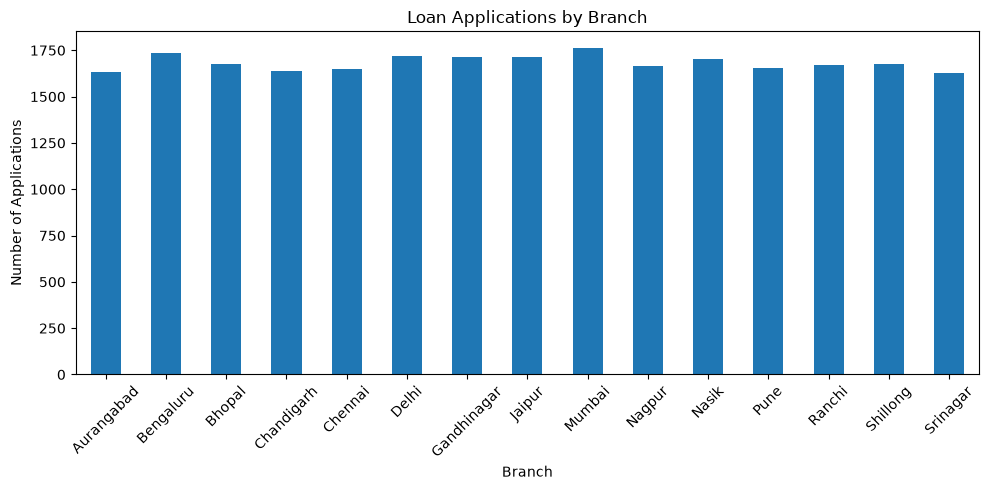

In [21]:

branch_report.plot(
    x='Branch Name',
    y='Applications',
    kind='bar',
    figsize=(10,5),
    legend=False
)

plt.title('Loan Applications by Branch')
plt.xlabel('Branch')
plt.ylabel('Number of Applications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Channel Report



### What is the performance of each channel in terms of applications, sanction amount and recovery amount?

In [22]:
channel_report = data.groupby(
    'Channels'
).agg(
    Applications=('Customer Number', 'nunique'),
    Sanction_Amount=('Sanction_Amount', 'sum'),
    Recovery_Amount=('Recovery_Amount', 'sum')
).reset_index()
channel_report = channel_report.sort_values(
    'Applications',
    ascending=False)

## Applications report

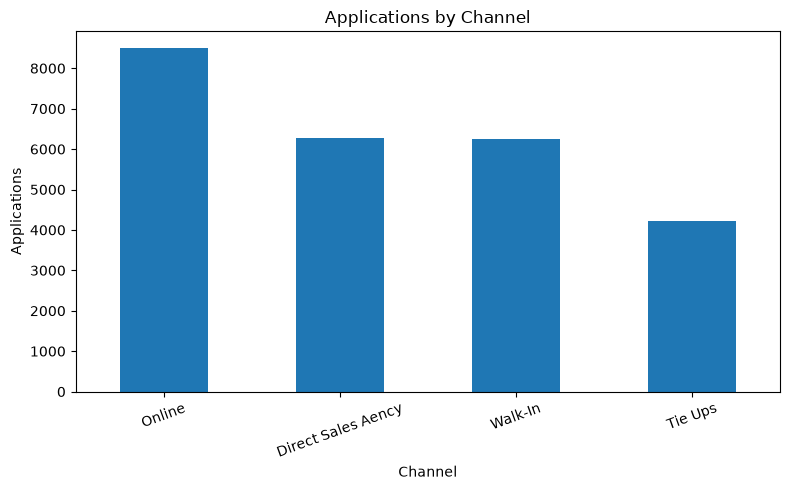

In [34]:
channel_report.plot(
    x='Channels',
    y='Applications',
    kind='bar',
    figsize=(8,5),
    legend=False
)

plt.title('Applications by Channel')
plt.xlabel('Channel')
plt.ylabel('Applications')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Sanction amount report

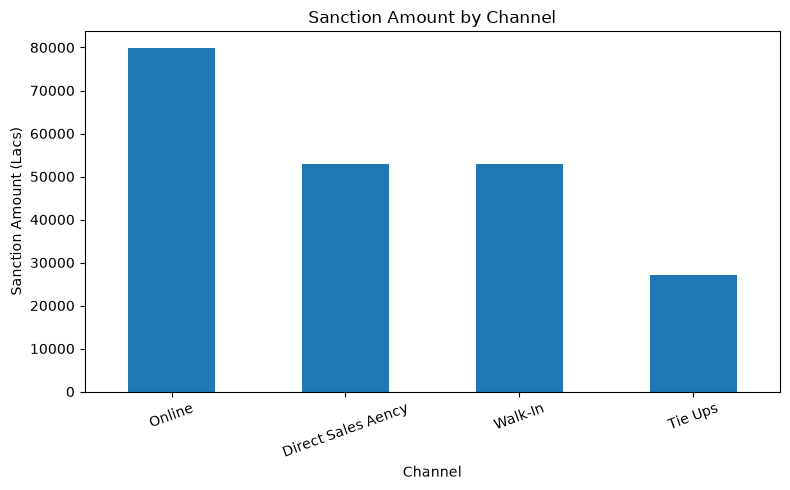

In [35]:
channel_report.plot(
    x='Channels',
    y='Sanction_Amount',
    kind='bar',
    figsize=(8,5),
    legend=False
)

plt.title('Sanction Amount by Channel')
plt.xlabel('Channel')
plt.ylabel('Sanction Amount (Lacs)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## recovery amount report

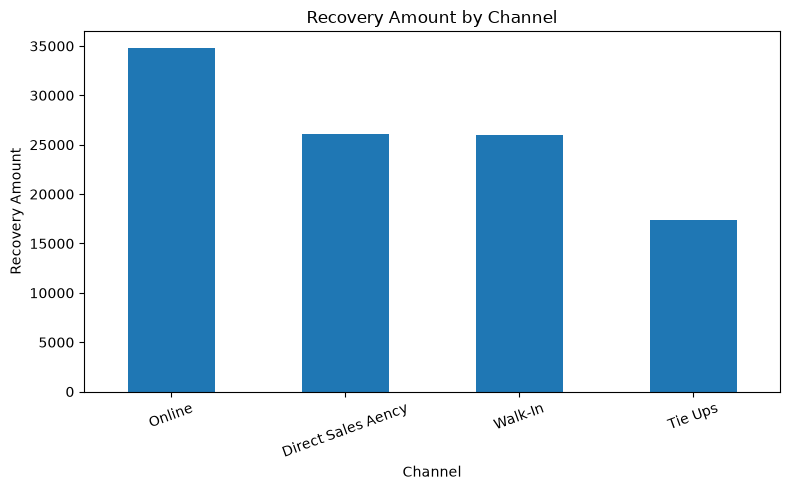

In [36]:
channel_report.plot(
    x='Channels',
    y='Recovery_Amount',
    kind='bar',
    figsize=(8,5),
    legend=False
)

plt.title('Recovery Amount by Channel')
plt.xlabel('Channel')
plt.ylabel('Recovery Amount')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# channel performance

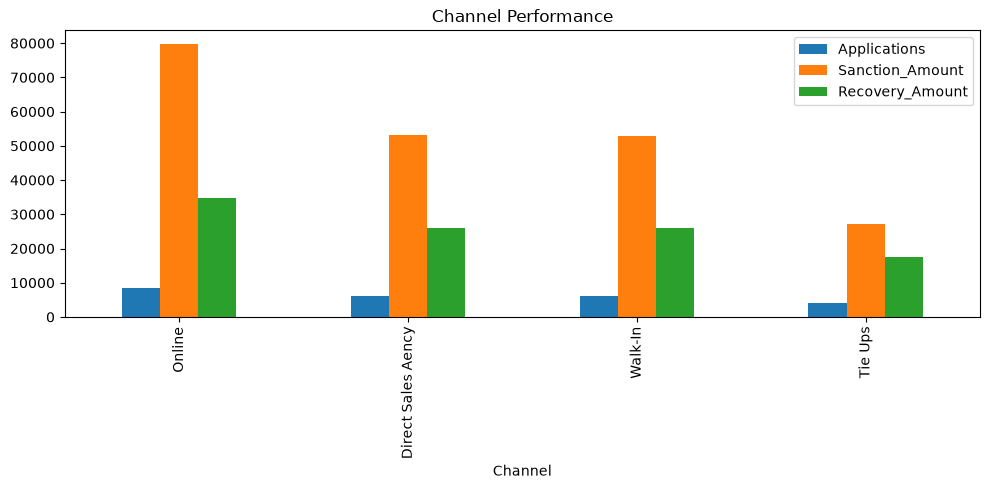

In [37]:
channel_report.plot(
    x='Channels',
    y=['Applications', 'Sanction_Amount', 'Recovery_Amount'],
    kind='bar',
    figsize=(10,5)
)

plt.title('Channel Performance')
plt.xlabel('Channel')
plt.tight_layout()
plt.show()

## Product Report

### Which product has the highest total sanctioned loan amount?

In [27]:
product_report = data.groupby(
    'Products'
).agg(
    Applications=('Customer Number', 'nunique'),
    Sanction_Amount=('Sanction_Amount', 'sum')
).reset_index()

In [29]:
#sorting 
product_report = product_report.sort_values(
    'Sanction_Amount',
    ascending=False)
product_report

,Products,Applications,Sanction_Amount
1,Loans + Group Insurance,6371,54131.0
3,Loans + Top-up,6267,53193.9
2,Loans + Individual Insurance,6428,53001.3
0,Loans,6170,52405.0


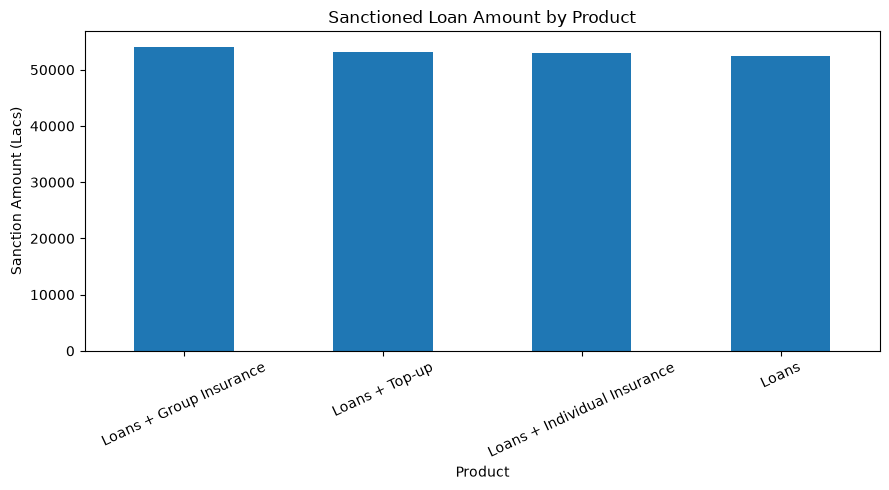

In [30]:
product_report.plot(
    x='Products',
    y='Sanction_Amount',
    kind='bar',
    figsize=(9,5),
    legend=False
)

plt.title('Sanctioned Loan Amount by Product')
plt.xlabel('Product')
plt.ylabel('Sanction Amount (Lacs)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Createing the final automated Excel report

In [31]:
with pd.ExcelWriter(
    'Home_Loan_Automated_Report.xlsx',
    engine='openpyxl'
) as writer:

    data.to_excel(
        writer,
        sheet_name='Master Data',
        index=False
    )

    kpi_report.to_excel(
        writer,
        sheet_name='KPI Report',
        index=False
    )

    branch_report.to_excel(
        writer,
        sheet_name='Branch Report',
        index=False
    )

    channel_report.to_excel(
        writer,
        sheet_name='Channel Report',
        index=False
    )

    product_report.to_excel(
        writer,
        sheet_name='Product Report',
        index=False
    )